In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 


In [120]:
pd.set_option('display.precision', 18)

In [43]:
be_3po_path = '/home/aldiyar/extrapolation/new-dataset/be_3po_test.csv'
be_3po = upload_basis(be_3po_path)
be_3po_err = upload_error(be_3po_path)
be_3po_init = be_3po.head(4)

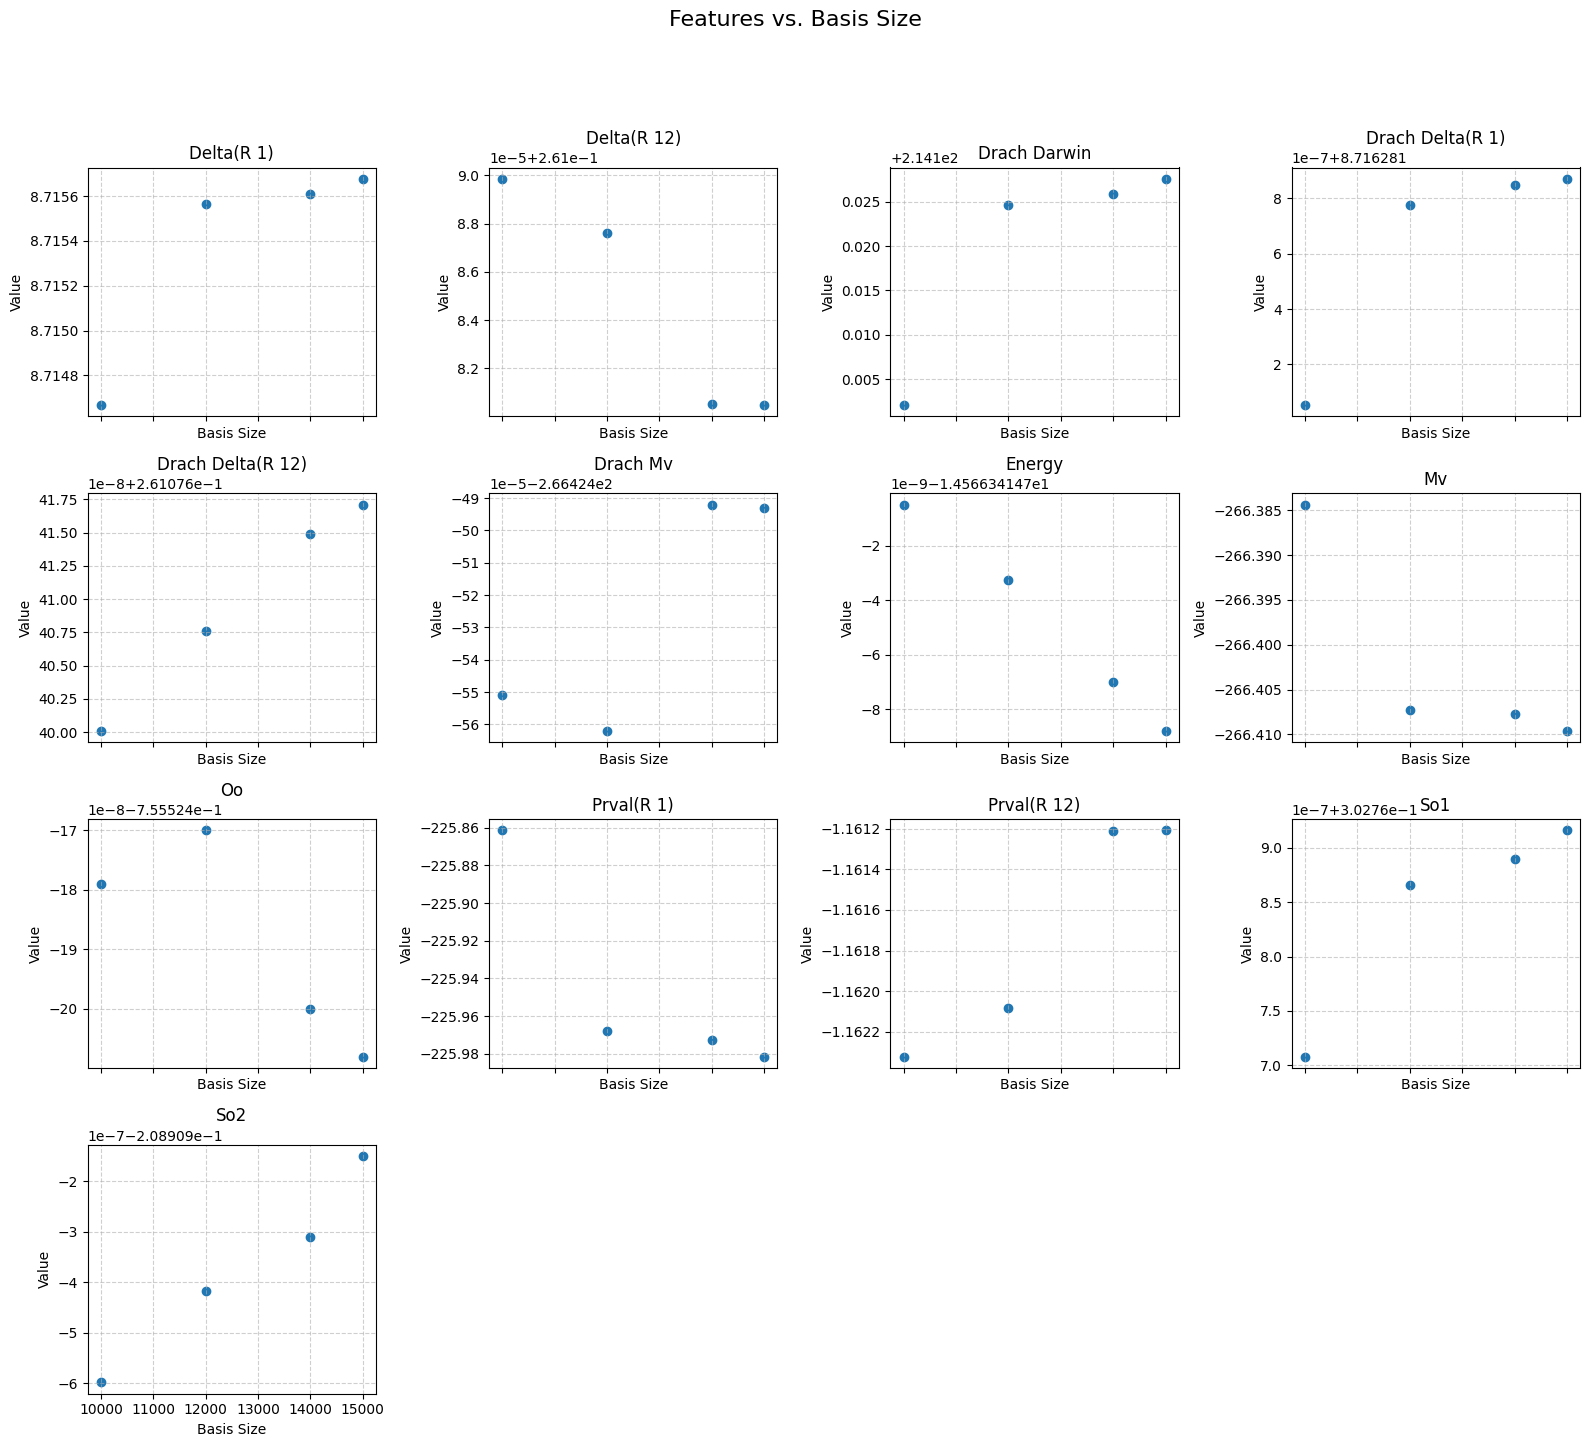

In [51]:
graph(be_3po_init)

In [2]:
def exponential_decay(x, C, A, B):

    return C + A * np.exp(-B * x)

x_scaled: [0.  0.4 0.8 1. ]
Linear trend: m = -1.678e-12, b = -1.457e+01
y_lin_start at x_min = -14.5663
A_guess = 8.53237e-09
Initial guesses: C=-14.5663, A=8.53237e-09, B=1.7
Iteration 0, weights: [0.53996753 0.65572124 1.10672004 1.69759118]
Iteration 1, weights: [0.3099513  0.48358186 1.16008007 2.04638678]

Fitted exponential parameters:
  C = -14.5663414788 ± 0.0000000112  (asymptote)
  A = 0.0000000085 ± 0.0000000107  (amplitude)
  B = 1.7000000000 ± 5.6571477601  (decay rate)
Fit quality: χ² = 7.840646e-18, RMSE = 1.400058e-09


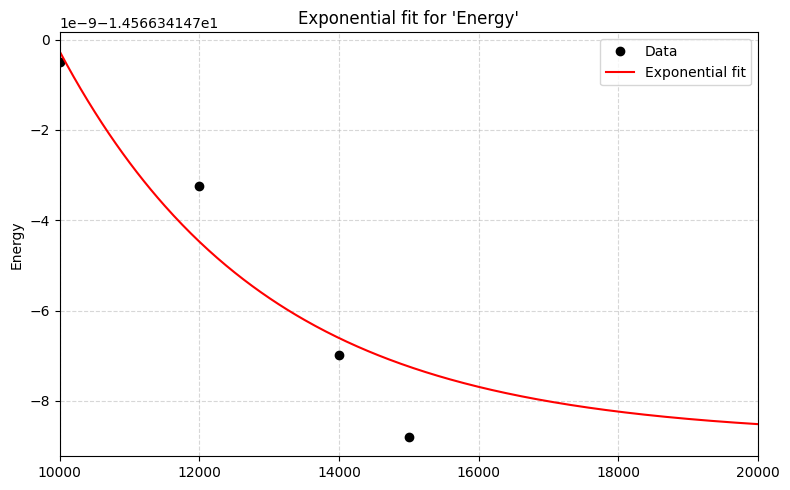

In [ ]:
import numpy as np
import pandas as pd
from lmfit import Model
import matplotlib.pyplot as plt


def exponential_decay(x, C, A, B):

    return C + A * np.exp(-B * x)


def _init_B_exponential(x_scaled, y, C=None):

    x_scaled = np.asarray(x_scaled, float)
    y = np.asarray(y, float)

    if C is None:
        C = y[-1]

    model = Model(exponential_decay)


    m, b = np.polyfit(x_scaled, y, 1) # LINEAR REGRESSION 
    x_start = x_scaled.min()          
    y_lin_start = m * x_start + b     # smoothed early value
    A0 = float(y_lin_start - C)


    y_span = float(np.max(y) - np.min(y))


    B_candidates = np.linspace(0.1, 10.0, 100)  
    best_B = None
    best_chi2 = np.inf

    for B0 in B_candidates:
        # Only C and A vary; B fixed
        params = model.make_params(C=C, A=A0, B=B0)
        params['B'].vary = False

        params['A'].set(min=-y_span, max=y_span)

        try:
            tmp_result = model.fit(y, params, x=x_scaled)
        except Exception:
            continue

        chi2 = np.sum(tmp_result.residual**2)
        if chi2 < best_chi2:
            best_chi2 = chi2
            best_B = B0

    return float(best_B)


def _fit_exponential_with_weights(y_data, x_scaled, params, weight_power=2):

    model = Model(exponential_decay)

    n_iterations = 100
    convergence_threshold = 1e-10
    current_weights = np.ones(len(x_scaled))

    for i in range(n_iterations):
        result = model.fit(y_data, params, x=x_scaled, weights=current_weights)

        # recompute weights using current B
        B_val = result.params['B'].value

        W_pos = np.exp(B_val * x_scaled)
        W_pos /= np.mean(W_pos)

        new_weights = W_pos**weight_power
        new_weights /= np.mean(new_weights)

        # smooth update
        current_weights = 0.5 * current_weights + 0.5 * new_weights
        print(f"Iteration {i}, weights: {current_weights}")

        old_params = np.array(list(params.valuesdict().values()))
        params = result.params
        new_params = np.array(list(params.valuesdict().values()))
        param_change = np.sum((old_params - new_params)**2)

        if param_change < convergence_threshold and i > 0:
            break

    return result


def fit_exponential_from_dataframe(df, column_name, max_x=None, known_convergent_value=None):

    #CHECK FOR THE EXISTENCE OF BASIS SIZE COLUMN 

    if 'basis size' not in df.columns:
        raise ValueError("DataFrame must contain a 'basis size' column.")

    # GET X AND Y VALUES
    x_data = np.asarray(df['basis size'].values, float)
    y_data = np.asarray(df[column_name].values, float)

    # scale x to [0,1]
    x_min = x_data.min()
    x_max = x_data.max()

    x_scaled = (x_data - x_min) / (x_max - x_min)

    print(f'x_scaled: {x_scaled}')

    # --- initial parameters ---
    model = Model(exponential_decay)
    params = model.make_params()

    C_guess = y_data[-1]
    params['C'].set(value=C_guess)

    m, b = np.polyfit(x_data, y_data, 1)
    x_start = x_data.min()
    y_lin_start = m * x_start + b

    A_guess = float(y_lin_start - C_guess)
    print(f"Linear trend: m = {m:.3e}, b = {b:.3e}")
    print(f"y_lin_start at x_min = {y_lin_start:.6g}")
    print(f"A_guess = {A_guess:.6g}")


    params['A'].set(value=A_guess)


    # --- B from grid-search over fixed B values, with a simple cap ---
    B_init = _init_B_exponential(x_scaled, y_data, C=C_guess)
    params['B'].set(value=B_init, min=1e-6, max=10.0)
    print(f"Initial guesses: C={C_guess:.6g}, A={A_guess:.6g}, B={B_init:.6g}")

    # --- fit (iteratively weighted) ---
    result = _fit_exponential_with_weights(y_data, x_scaled, params, weight_power=2)

    # diagnostics
    C = result.params['C'].value
    A = result.params['A'].value
    B = result.params['B'].value
    dC = result.params['C'].stderr if result.params['C'].stderr is not None else 0.0
    dA = result.params['A'].stderr if result.params['A'].stderr is not None else 0.0
    dB = result.params['B'].stderr if result.params['B'].stderr is not None else 0.0

    print("\nFitted exponential parameters:")
    print(f"  C = {C:.10f} ± {dC:.10f}  (asymptote)")
    print(f"  A = {A:.10f} ± {dA:.10f}  (amplitude)")
    print(f"  B = {B:.10f} ± {dB:.10f}  (decay rate)")

    residuals = result.residual
    chi2 = np.sum(residuals**2)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"Fit quality: χ² = {chi2:.6e}, RMSE = {rmse:.6e}")

    if known_convergent_value is not None:
        diff = C - known_convergent_value
        print(f"Known convergent value: {known_convergent_value:.10f}")
        print(f"Difference (C - known): {diff:.10f}")

    return result, dC


def plot_exponential_fit(df, column_name, result, max_x=None, show_residuals=False):

    x_data = np.asarray(df['basis size'].values, float)
    y_data = np.asarray(df[column_name].values, float)

    # Extrapolate curve up to 20000 by default
    if max_x is None:
        max_x = 20000.0

    # scaling must match fit_exponential_from_dataframe
    x_min = x_data.min()
    x_max_data = x_data.max()
    if x_max_data == x_min:
        raise ValueError("All x values identical; cannot scale.")
    x_scaled_data = (x_data - x_min) / (x_max_data - x_min)

    # dense grid for smooth curve up to max_x
    x_plot = np.linspace(x_min, max_x, 400)
    x_scaled_plot = (x_plot - x_min) / (x_max_data - x_min)

    # model predictions
    y_fit_data = result.eval(x=x_scaled_data)
    y_fit_plot = result.eval(x=x_scaled_plot)
    residuals = y_data - y_fit_data

    if show_residuals:
        fig, (ax_main, ax_res) = plt.subplots(
            2, 1, sharex=True,
            gridspec_kw={'height_ratios': [3, 1]},
            figsize=(8, 6)
        )
    else:
        fig, ax_main = plt.subplots(figsize=(8, 5))
        ax_res = None

    # main plot: data + extrapolated fit
    ax_main.plot(x_data, y_data, 'ko', label='Data')
    ax_main.plot(x_plot, y_fit_plot, 'r-', label='Exponential fit')
    ax_main.set_xlim(x_min, max_x)
    ax_main.set_ylabel(column_name)
    ax_main.set_title(f"Exponential fit for '{column_name}'")
    ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_main.legend()
    # plt.axhline(214.129287)

    # residuals
    if ax_res is not None:
        ax_res.axhline(0.0, color='k', linewidth=1, linestyle='--')
        ax_res.plot(x_data, residuals, 'bo-', label='Residuals')
        ax_res.set_xlabel('Basis size')
        ax_res.set_ylabel('resid')
        ax_res.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    result, dC = fit_exponential_from_dataframe(be_3po_init, "Energy")
    plot_exponential_fit(be_3po_init, "Energy", result, max_x=20000, show_residuals=False)